<h1 align = "center", style = "color:green;">Ridge and Lasso Regression Programming from Krish Naik<h1> 

<h2 style = "color: blue;">1.) Importing Libraries<h2>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
import seaborn as sns

## 2.) Reading the File

In [9]:
df = pd.read_csv("boston_house_prices.csv", header=1)

## 3.) Renaming the last Column

In [10]:
df.rename(columns={df.columns[-1]: "target"}, inplace=True)

## 4.) Declaring X and Y

In [ ]:
X = df.drop("target", axis=1)   # all feature columns
y = df["target"]                # target column

## 5.) Train-Test Split

In [ ]:
# Train-Test split
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.30, random_state=42)

## 6.) Normalizing Dataset 

In [ ]:
#Standardizing the dataset
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
'''
    For getting original Data You can always do
    X_train = scaler.inverse_transform(X_train)
'''

'\n    For getting original Data You can always do\n    X_train = scaler.inverse_transform(X_train)\n'

## 7.) Model Declaration

In [15]:
ridge_regressor = Ridge()

## 8.) Declaring Parameter and applying cross-validation

In [ ]:
parameter = {'alpha': [
    1, 
    2, 
    5, 
    10, 
    20, 
    30, 
    40, 
    50, 
    60, 
    70, 
    80, 
    90
]}

ridgecv = GridSearchCV(
    ridge_regressor, 
    parameter, 
    scoring = 'neg_mean_squared_error', 
    cv = 5
)
ridgecv.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter ind

## 9.) Printing best alpha Parameter

In [20]:
print(ridgecv.best_params_)

{'alpha': 10}


## 10.) Finding values to test Data

In [21]:
ridge_pred = ridgecv.predict(X_test)

## 11.) Understanding Error using Curve

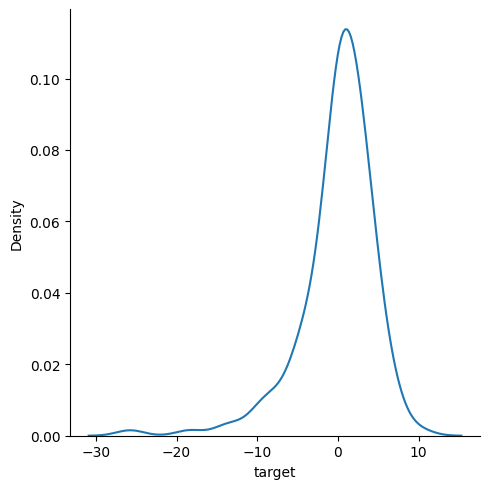

In [ ]:
sns.displot(ridge_pred-y_test, kind = 'kde')